In [8]:
%reload_ext autoreload
%autoreload 2

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from colmap_pair_dataset import ColmapPairDataset
from model import PairImageCylinderModel
from losses import supervised_loss, matched_radius_consistency_loss, matched_reprojection_loss_2d

from debugger import bug_check, debug_sinkhorn_matching


In [10]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=8,
    in_chans=3,
    embed_dim=384,
    depth=6,
    num_heads=6,
    num_bins=128,
    dropout=0.1,
).to(device)


In [12]:
BATCH_SIZE = 16 #8

train_dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    debug=False,
    return_two_pairs=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_dataset = SceneTwoPairsDataset(
    root_dir="valdataset",
    image_size=128,
    debug=False,
    return_two_pairs=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

forest_dataset = ColmapPairDataset(
    dataset_dir="forestdataset",
    image_size=128,
)

forest_loader = DataLoader(
    forest_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

In [13]:
# bug_check(0)
# debug_sinkhorn_matching(device="cuda")

In [14]:
LEARNING_RATE = 5e-4  # 1e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Hyperparameters
NUM_EPOCHS = 100
VAL_INTERVAL = 10
FOREST_START_EPOCH = 101

LAMBDA_OCC = 10.0
LAMBDA_RADIUS = 10.0
OCC_THRESH = 0.5

LAMBDA_REPROJ = 1.0
LAMBDA_RAD = 10.0
LAMBDA_FOREST_SPARSITY = 0.1

history = {
    "epoch": [],
    "total": [],
    "supervised": [],
    "vision": [],
    "pose": [],
    "radius_consistency": [],
    "reprojection": [],
    "forest_total": [],
    "forest_radius_consistency": [],
    "forest_reprojection": [],
    "forest_sparsity": [],
    "val_epoch": [],
    "val_total": [],
    "val_supervised": [],
    "val_vision": [],
    "val_pose": [],
    "val_radius_consistency": [],
    "val_reprojection": [],
}

for epoch in range(NUM_EPOCHS):
    epoch_num = epoch + 1

    model.train()
    train_totals = {
        "total": 0.0,
        "supervised": 0.0,
        "vision": 0.0,
        "pose": 0.0,
        "radius_consistency": 0.0,
        "reprojection": 0.0,
        "forest_total": 0.0,
        "forest_radius_consistency": 0.0,
        "forest_reprojection": 0.0,
        "forest_sparsity": 0.0,
    }

    forest_iter = iter(forest_loader) if epoch_num >= FOREST_START_EPOCH else None

    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)

        (img_a1, vision_a1, img_b1, vision_b1, pose_ab1,
         img_a2, vision_a2, img_b2, vision_b2, pose_ab2,
        ) = tuple(x.to(device, non_blocking=True) for x in batch)

        pred_vision_a1, pred_vision_b1, pred_pose1 = model(img_a1, img_b1)
        pred_vision_a2, pred_vision_b2, pred_pose2 = model(img_a2, img_b2)

        loss_out1 = supervised_loss(
            pred_vision_a1, vision_a1,
            pred_vision_b1, vision_b1,
            pred_pose1, pose_ab1,
            occ_thresh=OCC_THRESH, lambda_occ=LAMBDA_OCC, lambda_radius=LAMBDA_RADIUS)

        loss_out2 = supervised_loss(
            pred_vision_a2, vision_a2,
            pred_vision_b2, vision_b2,
            pred_pose2, pose_ab2,
            occ_thresh=OCC_THRESH, lambda_occ=LAMBDA_OCC, lambda_radius=LAMBDA_RADIUS)

        radius_cons1 = matched_radius_consistency_loss(pred_vision_a1, vision_a1, pred_vision_b1, vision_b1,
            relative_pose_pred=pred_pose1,
            matching_mode="gt", occ_thresh=OCC_THRESH)

        radius_cons2 = matched_radius_consistency_loss(pred_vision_a2, vision_a2, pred_vision_b2, vision_b2,
            relative_pose_pred=pred_pose2,
            matching_mode="gt", occ_thresh=OCC_THRESH)

        reproj1 = matched_reprojection_loss_2d(pred_vision_a1, vision_a1, pred_vision_b1, vision_b1, pred_pose1,
            matching_mode="gt", occ_thresh=OCC_THRESH, fov_degrees=90.0)

        reproj2 = matched_reprojection_loss_2d(pred_vision_a2, vision_a2, pred_vision_b2, vision_b2, pred_pose2,
            matching_mode="gt", occ_thresh=OCC_THRESH, fov_degrees=90.0)

        sup_loss = (loss_out1["total"] + loss_out2["total"]) / 2.0
        reproj = (reproj1 + reproj2) / 2.0
        radius_cons = (radius_cons1 + radius_cons2) / 2.0
        
        forest_loss = sup_loss.new_tensor(0.0)
        forest_radius_cons = sup_loss.new_tensor(0.0)
        forest_reproj = sup_loss.new_tensor(0.0)
        forest_sparsity = sup_loss.new_tensor(0.0)

        if forest_iter is not None:
            try:
                batch_forest = next(forest_iter)
            except StopIteration:
                forest_iter = iter(forest_loader)
                batch_forest = next(forest_iter)

            img_a_forest, img_b_forest, _ = tuple(x.to(device, non_blocking=True) for x in batch_forest)
            pred_vision_a_forest, pred_vision_b_forest, pred_pose_forest = model(img_a_forest, img_b_forest)

            forest_radius_cons = matched_radius_consistency_loss(pred_vision_a_forest, pred_vision_b=pred_vision_b_forest, relative_pose_pred=pred_pose_forest,
                matching_mode="sinkhorn", occ_thresh=OCC_THRESH)

            forest_reproj = matched_reprojection_loss_2d(pred_vision_a_forest, pred_vision_b=pred_vision_b_forest, relative_pose_pred=pred_pose_forest,
                matching_mode="sinkhorn", occ_thresh=OCC_THRESH, fov_degrees=90.0)

            forest_sparsity = (pred_vision_a_forest[..., 0].mean() + pred_vision_b_forest[..., 0].mean()) / 2.0

            forest_loss = LAMBDA_RAD * forest_radius_cons + LAMBDA_REPROJ * forest_reproj + LAMBDA_FOREST_SPARSITY * forest_sparsity

        loss = sup_loss # + 5.0 * radius_cons + 10.0 * reproj # + 10.0 * forest_loss
        loss.backward()
        optimizer.step()

        train_totals["total"] += loss.item()
        train_totals["supervised"] += sup_loss.item()
        train_totals["vision"] += ((loss_out1["vision_a"] + loss_out2["vision_a"]) / 2.0).item()
        train_totals["pose"] += ((loss_out1["pose"] + loss_out2["pose"]) / 2.0).item()
        train_totals["radius_consistency"] += radius_cons.item()
        train_totals["reprojection"] += reproj.item()
        train_totals["forest_total"] += forest_loss.item()
        train_totals["forest_radius_consistency"] += forest_radius_cons.item()
        train_totals["forest_reprojection"] += forest_reproj.item()
        train_totals["forest_sparsity"] += forest_sparsity.item()

    train_metrics = {key: value / len(train_loader) for key, value in train_totals.items()}

    forest_metrics = None

    if epoch_num >= FOREST_START_EPOCH:
        forest_metrics = {
            "total": train_metrics["forest_total"],
            "radius_consistency": train_metrics["forest_radius_consistency"],
            "reprojection": train_metrics["forest_reprojection"],
            "sparsity": train_metrics["forest_sparsity"],
        }

    history["epoch"].append(epoch_num)
    history["total"].append(train_metrics["total"])
    history["supervised"].append(train_metrics["supervised"])
    history["vision"].append(train_metrics["vision"])
    history["pose"].append(train_metrics["pose"])
    history["radius_consistency"].append(train_metrics["radius_consistency"])
    history["reprojection"].append(train_metrics["reprojection"])

    if forest_metrics is not None:
        history["forest_total"].append(forest_metrics["total"])
        history["forest_radius_consistency"].append(forest_metrics["radius_consistency"])
        history["forest_reprojection"].append(forest_metrics["reprojection"])
        history["forest_sparsity"].append(forest_metrics["sparsity"])
    else:
        history["forest_total"].append(None)
        history["forest_radius_consistency"].append(None)
        history["forest_reprojection"].append(None)
        history["forest_sparsity"].append(None)

    log = (
        f"Epoch {epoch_num}: "
        f"tot={train_metrics['total']:.4f} | "
        f"sup={train_metrics['supervised']:.4f} | "
        f"vis={train_metrics['vision']:.4f} | "
        f"pose={train_metrics['pose']:.4f} | "
        f"radius_cons={train_metrics['radius_consistency']:.4f} | "
        f"reproj={train_metrics['reprojection']:.4f}"
    )

    if forest_metrics is not None:
        log += (
            f" | forest_tot={forest_metrics['total']:.4f} | "
            f"forest_radius_cons={forest_metrics['radius_consistency']:.4f} | "
            f"forest_reproj={forest_metrics['reprojection']:.4f} | "
            f"forest_sparse={forest_metrics['sparsity']:.4f}"
        )

    if epoch_num == 1 or epoch_num % VAL_INTERVAL == 0:
        model.eval()
        val_totals = {
            "total": 0.0,
            "supervised": 0.0,
            "vision": 0.0,
            "pose": 0.0,
            "radius_consistency": 0.0,
            "reprojection": 0.0,
        }

        with torch.no_grad():
            for batch in val_loader:
                (img_a, vision_a, img_b, vision_b, pose_ab,
                ) = tuple(x.to(device, non_blocking=True) for x in batch)

                pred_vision_a, pred_vision_b, pred_pose = model(img_a, img_b)

                loss_out = supervised_loss(pred_vision_a, vision_a, pred_vision_b, vision_b, pred_pose, pose_ab,
                    occ_thresh=OCC_THRESH, lambda_occ=LAMBDA_OCC, lambda_radius=LAMBDA_RADIUS)

                sup_loss = loss_out["total"]

                radius_cons = matched_radius_consistency_loss(pred_vision_a, vision_a, pred_vision_b, vision_b,
                    relative_pose_pred=pred_pose,
                    matching_mode="gt", occ_thresh=OCC_THRESH)

                reproj = matched_reprojection_loss_2d(pred_vision_a, vision_a, pred_vision_b, vision_b, pred_pose,
                    matching_mode="gt", occ_thresh=OCC_THRESH, fov_degrees=90.0)

                val_totals["total"] += sup_loss.item()
                val_totals["supervised"] += sup_loss.item()
                val_totals["vision"] += loss_out["vision_a"].item()
                val_totals["pose"] += loss_out["pose"].item()
                val_totals["radius_consistency"] += radius_cons.item()
                val_totals["reprojection"] += reproj.item()

        val_metrics = {key: value / len(val_loader) for key, value in val_totals.items()}

        history["val_epoch"].append(epoch_num)
        history["val_total"].append(val_metrics["total"])
        history["val_supervised"].append(val_metrics["supervised"])
        history["val_vision"].append(val_metrics["vision"])
        history["val_pose"].append(val_metrics["pose"])
        history["val_radius_consistency"].append(val_metrics["radius_consistency"])
        history["val_reprojection"].append(val_metrics["reprojection"])

        log += (
            f" | val_tot={val_metrics['total']:.4f} | "
            f"val_sup={val_metrics['supervised']:.4f} | "
            f"val_vis={val_metrics['vision']:.4f} | "
            f"val_pose={val_metrics['pose']:.4f} | "
            f"val_radius_cons={val_metrics['radius_consistency']:.4f} | "
            f"val_reproj={val_metrics['reprojection']:.4f}"
        )

    print(log)

Epoch 1: tot=16.2868 | sup=16.2868 | vis=15.9586 | pose=0.3077 | radius_cons=0.0063 | reproj=0.0134 | val_tot=10.1894 | val_sup=10.1894 | val_vis=9.9099 | val_pose=0.2522 | val_radius_cons=0.0000 | val_reproj=0.0000
Epoch 2: tot=9.8325 | sup=9.8325 | vis=9.5567 | pose=0.2622 | radius_cons=0.0000 | reproj=0.0000
Epoch 3: tot=9.6522 | sup=9.6522 | vis=9.3842 | pose=0.2624 | radius_cons=0.0000 | reproj=0.0000
Epoch 4: tot=9.6249 | sup=9.6249 | vis=9.3504 | pose=0.2614 | radius_cons=0.0000 | reproj=0.0000
Epoch 5: tot=9.6389 | sup=9.6389 | vis=9.3671 | pose=0.2622 | radius_cons=0.0000 | reproj=0.0000
Epoch 6: tot=9.6224 | sup=9.6224 | vis=9.3444 | pose=0.2603 | radius_cons=0.0000 | reproj=0.0000
Epoch 7: tot=9.5655 | sup=9.5655 | vis=9.2913 | pose=0.2648 | radius_cons=0.0000 | reproj=0.0000
Epoch 8: tot=9.5856 | sup=9.5856 | vis=9.3023 | pose=0.2644 | radius_cons=0.0000 | reproj=0.0000
Epoch 9: tot=9.6208 | sup=9.6208 | vis=9.3454 | pose=0.2603 | radius_cons=0.0000 | reproj=0.0000
Epoch 10

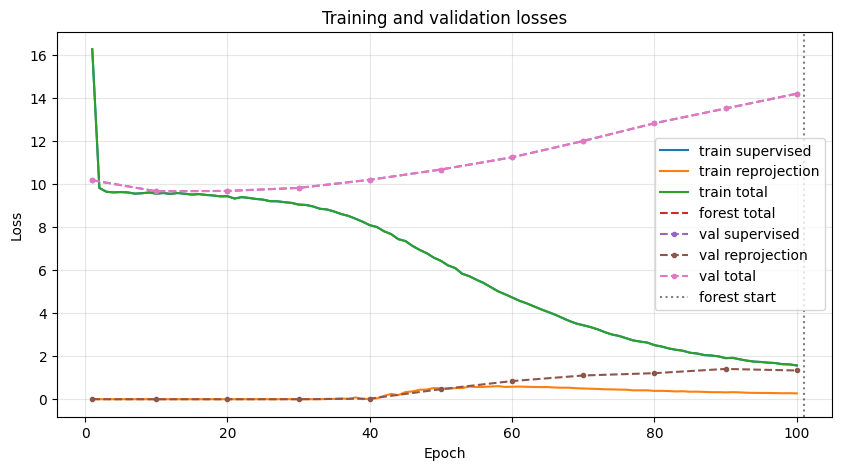

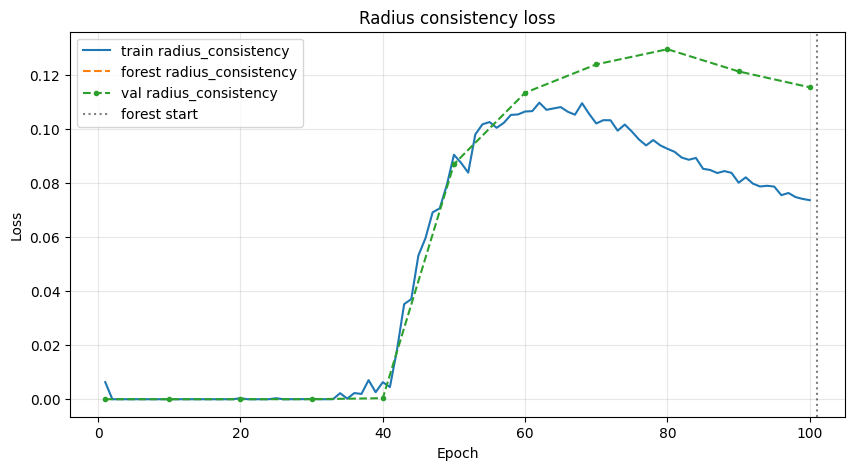

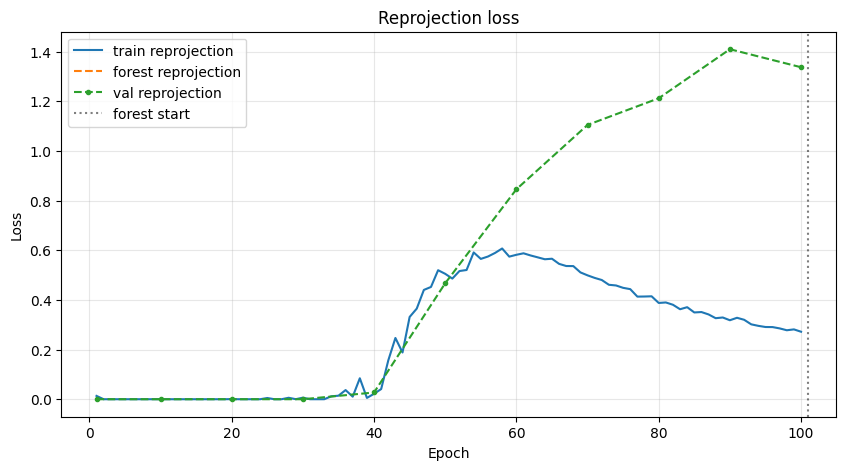

In [15]:
# Plot efter träning
epochs = np.array(history["epoch"])
val_epochs = np.array(history["val_epoch"])

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["supervised"], label="train supervised")
plt.plot(epochs, history["reprojection"], label="train reprojection")
plt.plot(epochs, history["total"], label="train total")
plt.plot(epochs, history["forest_total"],"--",label="forest total")

if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_supervised"], ".--", label="val supervised")
    plt.plot(val_epochs, history["val_reprojection"], ".--", label="val reprojection")
    plt.plot(val_epochs, history["val_total"], ".--", label="val total")

plt.axvline(FOREST_START_EPOCH,color="k",linestyle=":",alpha=0.5,label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation losses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(epochs, history["radius_consistency"], label="train radius_consistency")
plt.plot(epochs, history["forest_radius_consistency"],"--", label="forest radius_consistency")

if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_radius_consistency"],".--", label="val radius_consistency")

plt.axvline(FOREST_START_EPOCH,color="k",linestyle=":",alpha=0.5,label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Radius consistency loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(epochs, history["reprojection"],label="train reprojection")
plt.plot(epochs, history["forest_reprojection"],"--",label="forest reprojection")

if len(val_epochs) > 0:
    plt.plot(val_epochs, history["val_reprojection"],".--",label="val reprojection")

plt.axvline(FOREST_START_EPOCH,color="k",linestyle=":",alpha=0.5,label="forest start")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Reprojection loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [16]:
# Inference + utskrift + plottar på samma dataset som träningen
from utils import plot_estimated_cylinders_on_images, pose_to_text

infer_dataset = SceneTwoPairsDataset(
    root_dir="testdataset",
    return_two_pairs=False
)

infer_loader = DataLoader(
    infer_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
)
model.eval()

batch = next(iter(infer_loader))
img_a, vision_a, img_b, vision_b, pose_ab = batch

img_a = img_a.to(device)
vision_a = vision_a.to(device)
img_b = img_b.to(device)
vision_b = vision_b.to(device)
pose_ab = pose_ab.to(device)

with torch.no_grad():
    pred_vision, pred_vision_b, pred_pose = model(img_a, img_b)

if False:
    # Skriv ut resultat för några samples
    n_show = min(4, img_a.shape[0])
    for i in range(n_show):
        print(f"Sample {i}")
        print("  GT   pose:", pose_to_text(pose_ab[i].detach().cpu()))
        print("  Pred pose:", pose_to_text(pred_pose[i].detach().cpu()))

        pose_err = torch.abs(pred_pose[i] - pose_ab[i]).detach().cpu()
        print(f"  |err|     : tx={pose_err[0]:.3f}, ty={pose_err[1]:.3f}, sin={pose_err[2]:.3f}, cos={pose_err[3]:.3f}")
        print()

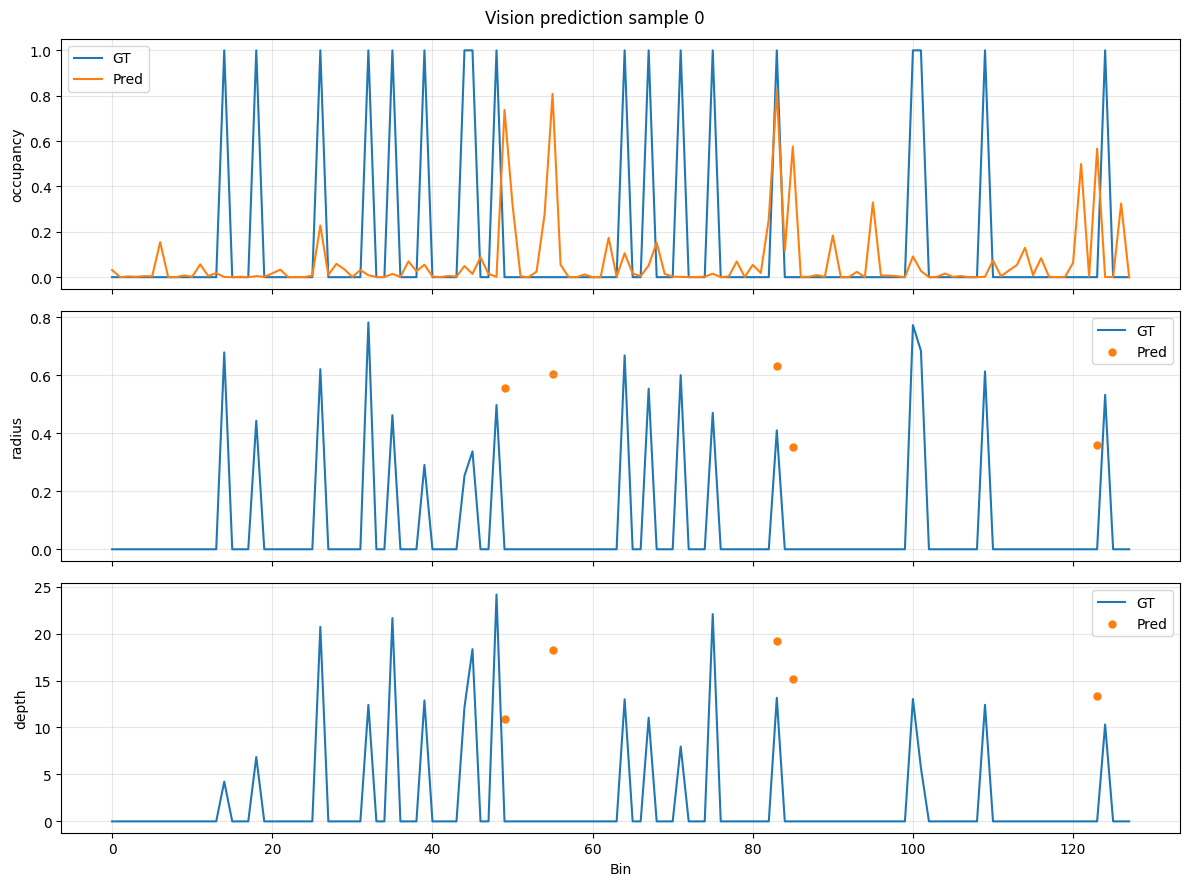

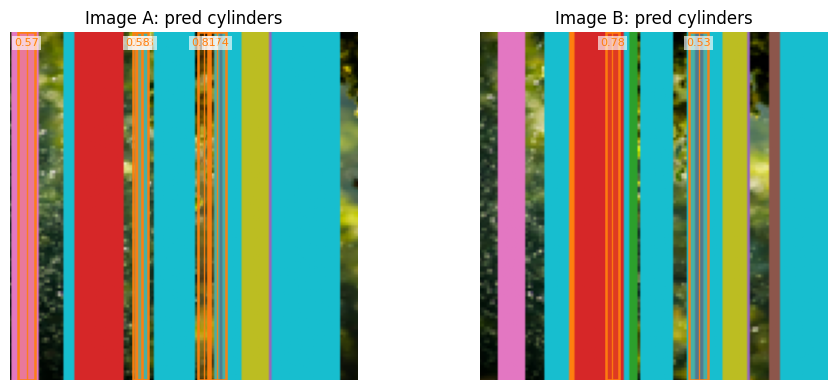

In [17]:
# Plotta vision-output för första samplet
sample_idx = 0
bins = np.arange(pred_vision.shape[1])

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

names = ["occupancy", "radius", "depth"]
occ_threshold = 0.5

gt_occ = vision_a[sample_idx, :, 0].detach().cpu().numpy()
pr_occ = pred_vision[sample_idx, :, 0].detach().cpu().numpy()

for j, ax in enumerate(axes):
    gt = vision_a[sample_idx, :, j].detach().cpu().numpy()
    pr = pred_vision[sample_idx, :, j].detach().cpu().numpy()

    # GT alltid blå linje
    ax.plot(bins, gt, label="GT", color="tab:blue")

    if j == 0:
        # occupancy: pred som orange linje
        ax.plot(bins, pr, label="Pred", color="tab:orange")
    else:
        pr_mask = pr_occ > occ_threshold

        # pred som orange punkter
        ax.scatter(
            bins[pr_mask],
            pr[pr_mask],
            label="Pred",
            color="tab:orange",
            s=25
        )

    ax.set_ylabel(names[j])
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Bin")
fig.suptitle(f"Vision prediction sample {sample_idx}")
plt.tight_layout()
plt.show()

# Plotta bildpar med estimerade cylindrar
fig_cyl, axes_cyl = plot_estimated_cylinders_on_images(
    [img_a[sample_idx], img_b[sample_idx]],
    [pred_vision[sample_idx], pred_vision_b[sample_idx]],
    titles=["Image A: pred cylinders", "Image B: pred cylinders"],
    occ_threshold=occ_threshold,
    flip_x=True,
)

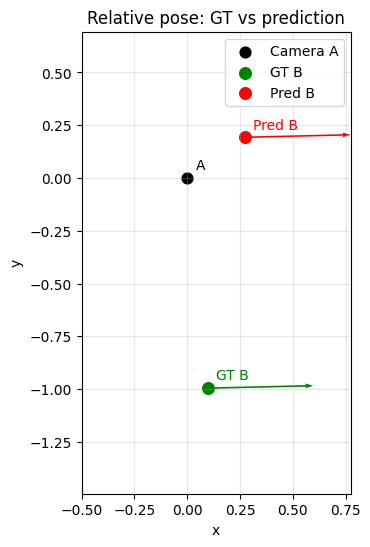

pred_vision shape: torch.Size([4, 128, 3])
pred_pose shape: torch.Size([4, 4])
GT pose: tensor([ 0.0971, -0.9953,  0.0234,  0.9997])
Pred pose: tensor([0.2741, 0.1931, 0.0239, 0.9997])


In [18]:
import matplotlib.pyplot as plt
import torch
import numpy as np

from utils import plot_relative_pose


# Visa första paret i batchen
if False:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_a[sample_idx].cpu().permute(1, 2, 0))
    axes[0].set_title("Image A")
    axes[0].axis("off")

    axes[1].imshow(img_b[sample_idx].cpu().permute(1, 2, 0))
    axes[1].set_title("Image B")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

# Visa relative pose
plot_relative_pose(pose_ab[sample_idx], pred_pose[sample_idx])

print("pred_vision shape:", pred_vision.shape)
print("pred_pose shape:", pred_pose.shape)
print("GT pose:", pose_ab[sample_idx].detach().cpu())
print("Pred pose:", pred_pose[sample_idx].detach().cpu())

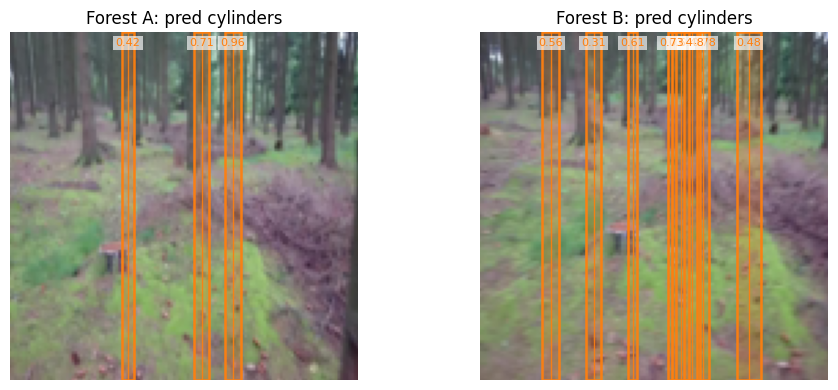

forest pred_vision_a shape: torch.Size([16, 128, 3])
forest pred_pose shape: torch.Size([16, 4])
forest pred_pose: tensor([ 0.4000,  0.0112, -0.0930,  0.9957])


: 

In [ ]:
# Plotta estimerade cylindrar på ett forest-sample
import torch

from utils import plot_estimated_cylinders_on_images

forest_sample_idx = 0
forest_occ_threshold = 0.3

model.eval()
forest_batch = next(iter(forest_loader))
img_a_forest, img_b_forest, _ = forest_batch

img_a_forest = img_a_forest.to(device)
img_b_forest = img_b_forest.to(device)

with torch.no_grad():
    pred_vision_a_forest, pred_vision_b_forest, pred_pose_forest = model(img_a_forest, img_b_forest)

fig_forest_cyl, axes_forest_cyl = plot_estimated_cylinders_on_images(
    [img_a_forest[forest_sample_idx], img_b_forest[forest_sample_idx]],
    [pred_vision_a_forest[forest_sample_idx], pred_vision_b_forest[forest_sample_idx]],
    titles=["Forest A: pred cylinders", "Forest B: pred cylinders"],
    occ_threshold=forest_occ_threshold,
    flip_x=True,
)

print("forest pred_vision_a shape:", pred_vision_a_forest.shape)
print("forest pred_pose shape:", pred_pose_forest.shape)
print("forest pred_pose:", pred_pose_forest[forest_sample_idx].detach().cpu())